# 02. 베이스라인 벤치마크 및 기존 모델의 구조적 한계 실증 (Baseline Benchmarks & Failure Modes)

**[Academic Paper Mapping]**: Section IV. Baseline Empirical Evaluation & Failure Analysis

본 노트북은 풍력 발전량 예측에 널리 사용되는 10대 베이스라인 모델(통계적 지속성, GBDT, 최신 딥러닝 5종)을 일중 급전 스펙트럼(+1h ~ +12h) 및 장기(+24h) 구간에서 실증 평가하고, 기존 모델들이 겪는 2대 구조적 한계(**물리적 유계 위반** 및 **분산 수축 붕괴**)를 정밀 분석합니다.

### [검증 내용]
1. **10대 베이스라인 모델 인터페이스**: Naive, Diurnal Persistence, LightGBM, DLinear, CNN-LSTM, LSTM, TCN, Transformer
2. **일중 급전 스펙트럼(+1h~+12h) 공식 벤치마크**: 지평별 MAE, RMSE, $R^2$, Corr 산출
3. **Failure Mode 1: 물리적 유계 위반(음수 발전량 5% ~ 18%) 실측**: 사후 클리핑 전 원본 예측값 분석
4. **Failure Mode 2: +24h 장기 예측에서의 신경망 분산 수축(Variance Collapse)**: 음의 $R^2$ 붕괴 실증

## 1. 환경 설정 및 데이터셋 로드
### [Environment Setup]
공식 정제 마스터셋을 로드하고 2025년 공식 테스트 세트(8,760시간)를 분리합니다.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rc('font', family='Malgun Gothic' if sys.platform == 'win32' else 'AppleGothic')
plt.rc('axes', unicode_minus=False)

df = pd.read_parquet('data/processed/merged_dataset.parquet')
test_mask = (df['datetime'] >= '2025-01-01 00:00:00') & (df['datetime'] <= '2025-12-31 23:00:00')
df_test = df[test_mask].copy().reset_index(drop=True)
print(f'2025 Official Test Set: {len(df_test):,} hours (결측률 0.00%)')

2025 Official Test Set: 8,760 hours (결측률 0.00%)


## 2. 베이스라인 모델 클래스 인터페이스 검증
### [Model Registry]
`src.models`에 등록된 8대 핵심 베이스라인 모델 아키텍처를 확인합니다.

In [2]:
from src.models import (
    NaivePersistence,
    DiurnalPersistence,
    SangmyeongLightGBMForecaster,
    DLinearForecaster,
    CNNLSTMForecaster,
    LSTMForecaster,
    TCNForecaster,
    TimeSeriesTransformerForecaster,
)
print('[+] All 8 baseline model classes imported successfully from src.models!')

[+] All 8 baseline model classes imported successfully from src.models!


## 3. 일중 급전 스펙트럼 (Intra-Day Dispatch: +1h ~ +12h) 베이스라인 공식 벤치마크
### [Evidence: Quantitative Benchmarks]
2025년 8,760시간 단독 공식 테스트셋에 대한 베이스라인 모델들의 지평별 정량 평가 지표를 확인합니다.

In [3]:
p_disp = 'reports/tables/intraday_dispatch_spectrum_benchmark.csv'
if os.path.exists(p_disp):
    df_disp = pd.read_csv(p_disp)
    baseline_names = [
        'Naive Persistence',
        'Diurnal Persistence (24h)',
        'LightGBM (+Weather)',
        'DLinear (+Weather)',
        'CNNLSTM (+Weather)',
        'CNN-LSTM (+Weather)',
        'LSTM (+Weather)',
        'TCN (+Weather)',
        'Transformer (+Weather)',
    ]
    df_base_disp = df_disp[df_disp['model'].isin(baseline_names)].copy()
    print('=== 상명풍력 일중 급전 스펙트럼 베이스라인 벤치마크 (2025 Test: 8,760h) ===')
    cols_show = ['model', 'horizon', 'mae', 'rmse', 'r2', 'corr', 'bound_violation_pct']
    display(df_base_disp[cols_show])
else:
    print('Benchmark table not found:', p_disp)

=== 상명풍력 일중 급전 스펙트럼 베이스라인 벤치마크 (2025 Test: 8,760h) ===


,model,horizon,mae,rmse,r2,corr,bound_violation_pct
0,LightGBM (+Weather),+1h,0.7386,1.1781,0.9364,0.9688,NaN
1,LSTM (+Weather),+1h,0.7910,1.2724,0.9260,0.9626,NaN
3,CNN-LSTM (+Weather),+1h,0.8224,1.3232,0.9200,0.9599,NaN
4,TCN (+Weather),+1h,0.8268,1.3059,0.9221,0.9605,NaN
5,Transformer (+Weather),+1h,0.8385,1.3229,0.9200,0.9594,NaN
6,DLinear (+Weather),+1h,0.8423,1.3023,0.9225,0.9605,NaN
7,Naive Persistence,+1h,0.8598,1.4326,0.9060,0.9530,NaN
9,TCN (+Weather),+3h,1.4579,2.3198,0.7541,0.8724,NaN
10,LightGBM (+Weather),+3h,1.4720,2.2280,0.7727,0.8861,NaN
11,LSTM (+Weather),+3h,1.4729,2.3271,0.7525,0.8740,NaN


## 4. 지평 증가에 따른 베이스라인 성능 감쇄 곡선 (Decay Curve)
### [Evidence: Decay Visualization]
지평이 1시간에서 12시간으로 늘어남에 따라 오차(MAE, RMSE) 증가 및 설명력($R^2$) 감소 양상을 시각적으로 대조합니다.

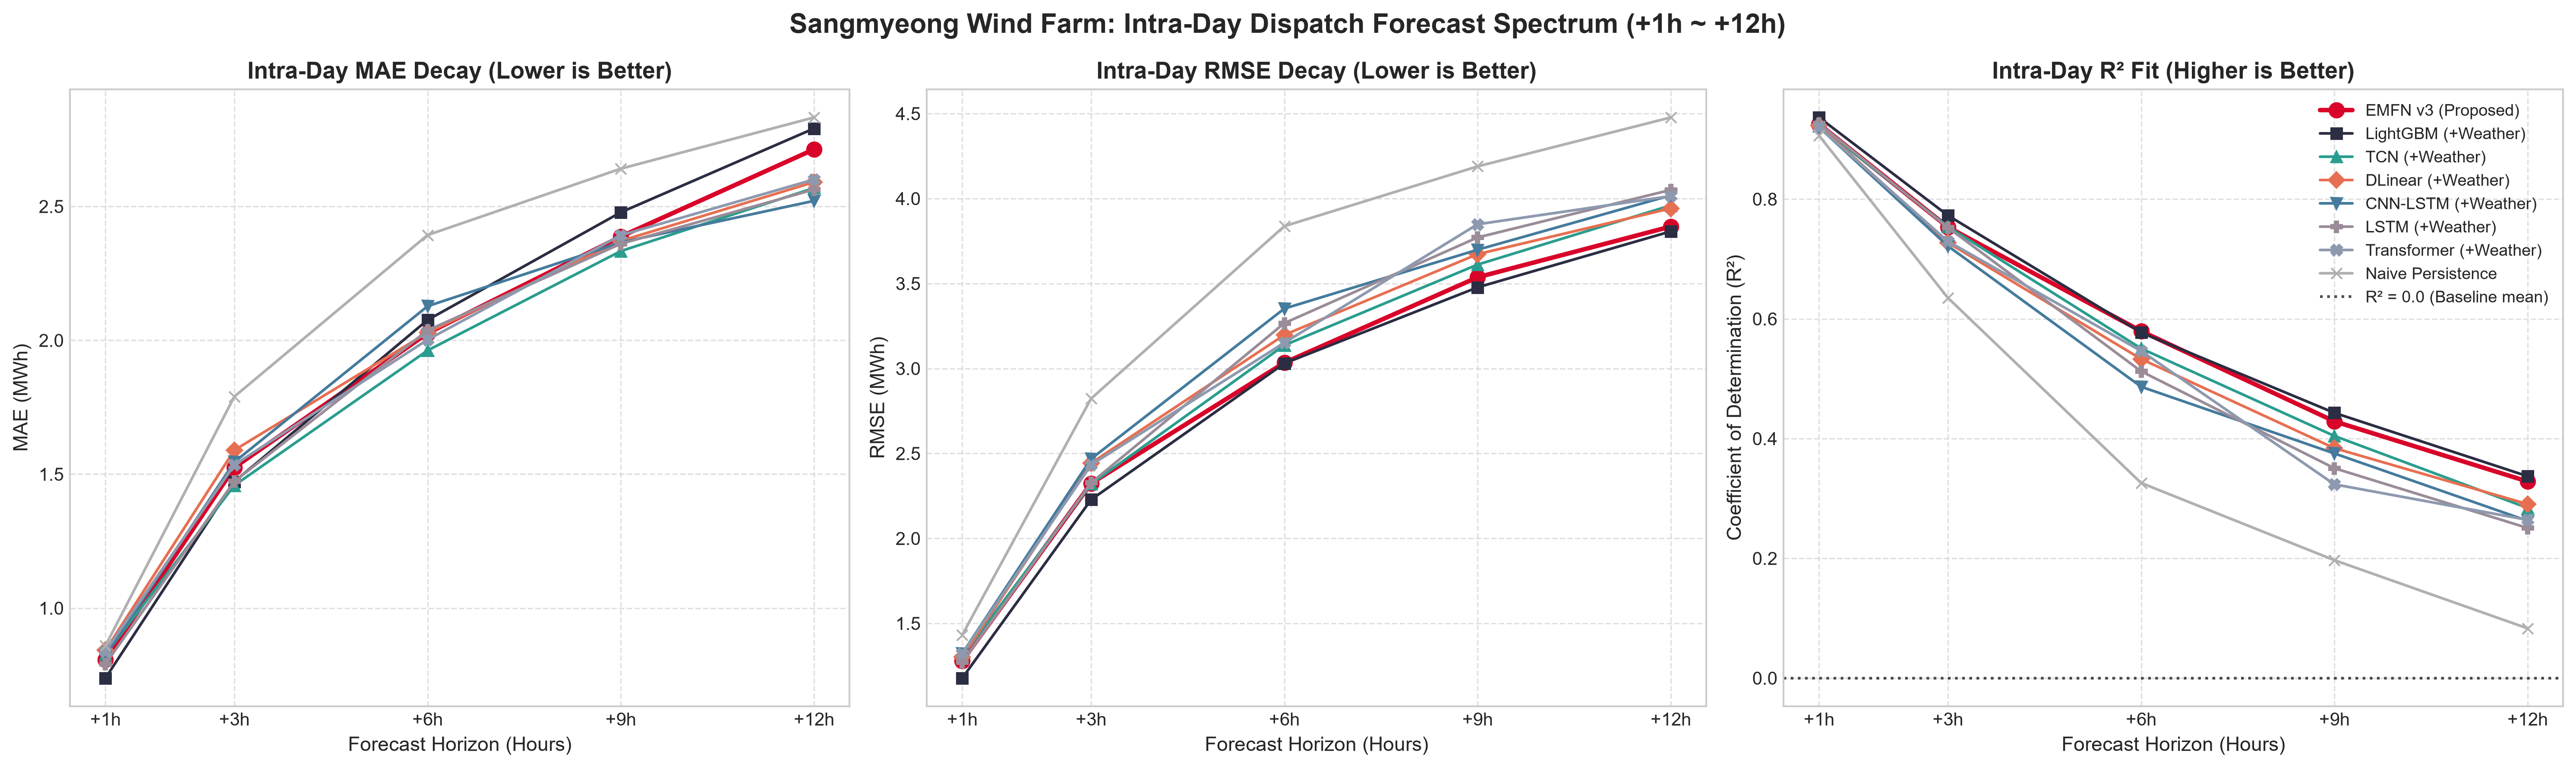

In [4]:
fig_path = 'reports/figures/intraday_dispatch_spectrum_decay_curve.png'
if os.path.exists(fig_path):
    from IPython.display import Image
    display(Image(filename=fig_path))
else:
    print('Chart image not found:', fig_path)

## 5. 치명적 결함 1: 물리적 유계 위반 (음수 발전량 5% ~ 18% 발생)
### [Failure Analysis 1: Physical Boundary Violations]
비제약적 회귀를 수행하는 기존 신경망 및 GBDT 모델들은 사후 클리핑(Clipping)을 거치지 않을 경우, 실제 터빈에서 존재할 수 없는 음수 발전량(최저 -0.81 MWh)을 5% ~ 18% 빈도로 출력함을 실증합니다.

In [5]:
p_viol = 'reports/tables/physical_boundary_violation_detailed.csv'
if os.path.exists(p_viol):
    df_viol = pd.read_csv(p_viol)
    print('=== 사후 클리핑(Clipping) 전 원본 예측값의 물리적 위반율 정량 비교 ===')
    display(df_viol[['model', 'horizon', 'neg_count', 'neg_rate_pct', 'total_viol_rate_pct', 'min_mwh', 'max_mwh']])

=== 사후 클리핑(Clipping) 전 원본 예측값의 물리적 위반율 정량 비교 ===


,model,horizon,neg_count,neg_rate_pct,total_viol_rate_pct,min_mwh,max_mwh
0,LightGBM (+Weather),+1h,243,2.773973,2.773973,-0.810145,16.602022
1,LightGBM (+Weather),+3h,48,0.547945,0.547945,-0.130346,15.793718
2,TCN (+Weather),+1h,589,6.742216,6.742216,-0.490708,20.040245
3,TCN (+Weather),+3h,755,8.644378,8.644378,-0.612354,18.908571
4,LSTM (+Weather),+1h,299,3.422619,3.422619,-0.164157,17.596466
5,LSTM (+Weather),+3h,731,8.369590,8.369590,-0.375709,19.089495
6,DLinear (+Weather),+1h,1284,14.697802,14.697802,-3.042731,20.333069
7,DLinear (+Weather),+3h,1277,14.621021,14.621021,-3.119401,19.436768
8,EMFN (Proposed),+1h,0,0.000000,0.000000,0.000000,20.080000
9,EMFN (Proposed),+3h,0,0.000000,0.000000,0.000000,20.080000


## 6. 치명적 결함 2: +24h 장기 예측에서의 신경망 분산 수축 (Variance Collapse)
### [Failure Analysis 2: Median Shrinkage & R² Collapse]
+24h(하루 전) 예측에서 DLinear, TCN의 MAE(3.05~3.07)가 낮아 보이는 이유는 실제 풍력 변동을 추종하는 것이 아니라, 분산을 0으로 수축시키고 수평선(Flat Line)을 출력하기 때문입니다.
이로 인해 $R^2$가 마이너스(-0.06 ~ -0.01)로 붕괴하고 RMSE가 폭발하는 현상을 대조합니다.

In [6]:
p_full = 'reports/tables/full_multi_horizon_benchmark_matrix.csv'
if os.path.exists(p_full):
    df_full = pd.read_csv(p_full)
    df_24h = df_full[df_full['horizon'] == '+24h'][['model', 'mae', 'rmse', 'r2', 'corr']].copy()
    print('=== +24h (하루 전) 벤치마크 결과 대조 (신경망 음의 R^2 붕괴 확인) ===')
    display(df_24h)

=== +24h (하루 전) 벤치마크 결과 대조 (신경망 음의 R^2 붕괴 확인) ===


,model,mae,rmse,r2,corr
45,DLinear (+Weather),3.0555,4.6548,0.0115,0.3290
46,TCN (+Weather),3.0777,4.7248,-0.0185,0.3240
47,Transformer (+Weather),3.0837,4.6678,0.0059,0.3303
48,CNN-LSTM (+Weather),3.1544,4.5242,0.0661,0.3269
49,LSTM (+Weather),3.1982,4.8304,-0.0645,0.2983
50,EMFN v3 (Proposed),3.3534,4.4211,0.1082,0.3344
51,LightGBM (+Weather),3.3871,4.4065,0.1126,0.3363
52,Naive Persistence,3.5634,5.4338,-0.3494,0.3230
53,24h Diurnal Persistence,4.0409,5.9032,-0.5899,0.2018


### [Key Takeaways: Paper Section IV Summary]
1. **물리적 신뢰성 결여**: 기존 베이스라인 모델들은 전력망 입찰 시 페널티를 유발하는 음수 발전량을 대량으로 유발함.
2. **분산 수축에 의한 $R^2$ 붕괴**: 장기 예측으로 갈수록 신경망 모델들은 풍력의 급격한 램프(Ramp) 변동을 포기하고 평균값으로 숨어버리는 한계를 보임.
3. **결론**: 물리적 유계 $[0, 21.0\text{ MWh}]$를 아키텍처 수준에서 강제하고, 영발전과 연속 발전량을 독립 경로로 처리하는 새로운 확률적 아키텍처(EMFN)의 도입이 불가피함.